In [ ]:

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import warnings

# **Step 1**

###  Step 1a

In [ ]:
end_date = datetime.now()
start_date = end_date - timedelta(days=3000)  # Get more data to ensure 2000 observations
eth_data = yf.download('ETH-USD', start=start_date, end=end_date)

# Take last 2000 observations
eth_data = eth_data.tail(2000).copy()
print(f"Data shape: {eth_data.shape}")
print(f"Date range: {eth_data.index[0]} to {eth_data.index[-1]}")

<ipython-input-50-3004229765>:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eth_data = yf.download('ETH-USD', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Data shape: (2000, 5)
Date range: 2019-12-27 00:00:00 to 2025-06-17 00:00:00


In [ ]:
#Reduce Shape Size
eth_data = eth_data.tail(2000).copy()
print(f"Data shape: {eth_data.shape}")
print(f"Date range: {eth_data.index[0]} to {eth_data.index[-1]}")

eth_data.head()

Data shape: (2000, 5)
Date range: 2019-12-27 00:00:00 to 2025-06-17 00:00:00


Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2019-12-27,127.214607,128.097565,124.820808,126.368797,8299390176
2019-12-28,128.322708,130.258163,126.899696,127.213013,8069298610
2019-12-29,134.757980,136.811203,127.997658,128.266876,9708776786
2019-12-30,132.633484,136.757355,131.545563,134.796524,9796951716
2019-12-31,129.610855,133.732681,128.798157,132.612274,8936866397


In [ ]:

# Step 1 B. Feature Engineering with INTENTIONAL DATA LEAKAGE

def calculate_rsi(prices, window=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


# Basic features
eth_data['Returns'] = eth_data['Close'].pct_change()
eth_data['Log_Returns'] = np.log(eth_data['Close'] / eth_data['Close'].shift(1))
eth_data['Volatility'] = eth_data['Returns'].rolling(window=10).std()
eth_data['MA_5'] = eth_data['Close'].rolling(window=5).mean()
eth_data['MA_20'] = eth_data['Close'].rolling(window=20).mean()
eth_data['RSI'] = calculate_rsi(eth_data['Close'], 14)

# Future price changes (LEAKAGE)
eth_data['Future_Return_1d'] = eth_data['Returns'].shift(-1)
eth_data['Future_Return_3d'] = eth_data['Returns'].shift(-3)
eth_data['Future_Return_5d'] = eth_data['Returns'].shift(-5)

# Future volatility (LEAKAGE)
eth_data['Future_Volatility'] = eth_data['Volatility'].shift(-5)

# Forward-looking moving averages (LEAKAGE)
eth_data['Forward_MA_5'] = eth_data['Close'].shift(-5).rolling(window=5).mean()

# Technical indicators
eth_data['Price_Change'] = eth_data['Close'] - eth_data['Open']
eth_data['High_Low_Ratio'] = eth_data['High'] / eth_data['Low']
eth_data['Volume_MA'] = eth_data['Volume'].rolling(window=10).mean()


eth_data.head(30)

Price,Close,High,Low,Open,Volume,Returns,Log_Returns,Volatility,MA_5,MA_20,RSI,Future_Return_1d,Future_Return_3d,Future_Return_5d,Future_Volatility,Forward_MA_5,Price_Change,High_Low_Ratio,Volume_MA
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,
2019-12-27,127.214607,128.097565,124.820808,126.368797,8299390176,NaN,NaN,NaN,NaN,NaN,NaN,0.008710,-0.015765,0.009190,NaN,NaN,0.845810,1.026252,NaN
2019-12-28,128.322708,130.258163,126.899696,127.213013,8069298610,0.008710,0.008673,NaN,NaN,NaN,NaN,0.050149,-0.022789,-0.025931,NaN,NaN,1.109695,1.026466,NaN
2019-12-29,134.757980,136.811203,127.997658,128.266876,9708776786,0.050149,0.048932,NaN,NaN,NaN,NaN,-0.015765,0.009190,0.053069,NaN,NaN,6.491104,1.068857,NaN
2019-12-30,132.633484,136.757355,131.545563,134.796524,9796951716,-0.015765,-0.015891,NaN,NaN,NaN,NaN,-0.022789,-0.025931,0.006690,NaN,NaN,-2.163040,1.039620,NaN
2019-12-31,129.610855,133.732681,128.798157,132.612274,8936866397,-0.022789,-0.023053,NaN,130.507927,NaN,NaN,0.009190,0.053069,0.008939,NaN,132.746007,-3.001419,1.038312,NaN
2020-01-01,130.802002,132.835358,129.198288,129.630661,7935230330,0.009190,0.009148,NaN,131.225406,NaN,NaN,-0.025931,0.006690,0.058905,0.031280,135.446437,1.171341,1.028151,NaN
2020-01-02,127.410179,130.820038,126.954910,130.820038,8032709256,-0.025931,-0.026273,NaN,131.042900,NaN,NaN,0.053069,0.008939,-0.005268,0.031807,138.673199,-3.409859,1.030445,NaN
2020-01-03,134.171707,134.554016,126.490021,127.411263,10476845358,0.053069,0.051709,NaN,130.925645,NaN,NaN,0.006690,0.058905,-0.015924,0.029731,140.090485,6.760445,1.063752,NaN


In [ ]:
eth_data.dropna(inplace=True)
eth_data.head()


(1976, 19)

In [ ]:
# Regression target: Next day return
eth_data['Target_Return'] = eth_data['Returns'].shift(-1)

# Classification target: Direction (Up/Down)
eth_data['Target_Direction'] = (eth_data['Target_Return'] > 0).astype(int)

# Multi-class classification: Strong Down, Down, Up, Strong Up
conditions = [
    eth_data['Target_Return'] <= -0.02,
    (eth_data['Target_Return'] > -0.02) & (eth_data['Target_Return'] <= 0),
    (eth_data['Target_Return'] > 0) & (eth_data['Target_Return'] <= 0.02),
    eth_data['Target_Return'] > 0.02
]
choices = [0, 1, 2, 3]  # Strong Down, Down, Up, Strong Up
eth_data['Target_Multiclass'] = np.select(conditions, choices, default=1)

# Clean data
eth_data = eth_data.dropna()
print(f"Final data shape after cleaning: {eth_data.shape}")


Final data shape after cleaning: (1975, 22)


In [ ]:
#Prep the features

feature_cols = ['Returns', 'Log_Returns', 'Volatility', 'MA_5', 'MA_20', 'RSI',
                'Future_Return_1d', 'Future_Return_3d', 'Future_Return_5d',
                'Future_Volatility', 'Forward_MA_5', 'Price_Change',
                'High_Low_Ratio', 'Volume_MA']

X = eth_data[feature_cols].values
y_reg = eth_data['Target_Return'].values
y_class = eth_data['Target_Direction'].values
y_multi = eth_data['Target_Multiclass'].values


In [ ]:
# 5. Train/Test Split (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_reg_train, y_reg_test = y_reg[:split_idx], y_reg[split_idx:]
y_class_train, y_class_test = y_class[:split_idx], y_class[split_idx:]
y_multi_train, y_multi_test = y_multi[:split_idx], y_multi[split_idx:]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1580
Testing samples: 395


### Step 1b

###MLP Model

In [ ]:
def build_mlp_model(input_dim, task='regression'):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2)
    ])

    if task == 'regression':
        model.add(Dense(1, activation='linear'))
        model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    elif task == 'binary':
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    else:  # multiclass
        model.add(Dense(4, activation='softmax'))
        model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model


# Train MLP models
mlp_reg = build_mlp_model(X_train_scaled.shape[1], 'regression')
mlp_class = build_mlp_model(X_train_scaled.shape[1], 'binary')
mlp_multi = build_mlp_model(X_train_scaled.shape[1], 'multiclass')

print("Training MLP models...")
mlp_reg.fit(X_train_scaled, y_reg_train, epochs=50, batch_size=32, verbose=0, validation_split=0.2)
mlp_class.fit(X_train_scaled, y_class_train, epochs=50, batch_size=32, verbose=0, validation_split=0.2)
mlp_multi.fit(X_train_scaled, y_multi_train, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training MLP models...


### LSTM Model


In [ ]:
def create_sequences(data, targets, seq_length=10):
    """Create sequences for LSTM with properly aligned targets"""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(targets[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X_train_seq, y_reg_train_seq = create_sequences(X_train_scaled, y_reg_train, seq_length)
X_test_seq, y_reg_test_seq = create_sequences(X_test_scaled, y_reg_test, seq_length)

# Create sequences for classification targets too
_, y_class_train_seq = create_sequences(X_train_scaled, y_class_train, seq_length)
_, y_class_test_seq = create_sequences(X_test_scaled, y_class_test, seq_length)
_, y_multi_train_seq = create_sequences(X_train_scaled, y_multi_train, seq_length)
_, y_multi_test_seq = create_sequences(X_test_scaled, y_multi_test, seq_length)

print(f"LSTM sequence shapes:")
print(f"X_train_seq: {X_train_seq.shape}")
print(f"X_test_seq: {X_test_seq.shape}")
print(f"y_reg_train_seq: {y_reg_train_seq.shape}")
print(f"y_reg_test_seq: {y_reg_test_seq.shape}")

def build_lstm_model(input_shape, task='regression'):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(16, activation='relu')
    ])

    if task == 'regression':
        model.add(Dense(1, activation='linear'))
        model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    elif task == 'binary':
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    else:  # multiclass
        model.add(Dense(4, activation='softmax'))
        model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Train LSTM models
lstm_reg = build_lstm_model((seq_length, X_train_scaled.shape[1]), 'regression')
lstm_class = build_lstm_model((seq_length, X_train_scaled.shape[1]), 'binary')
lstm_multi = build_lstm_model((seq_length, X_train_scaled.shape[1]), 'multiclass')

print("Training LSTM models...")
lstm_reg.fit(X_train_seq, y_reg_train_seq, epochs=50, batch_size=32, verbose=0, validation_split=0.2)
lstm_class.fit(X_train_seq, y_class_train_seq, epochs=50, batch_size=32, verbose=0, validation_split=0.2)
lstm_multi.fit(X_train_seq, y_multi_train_seq, epochs=50, batch_size=32, verbose=0, validation_split=0.2)


LSTM sequence shapes:
X_train_seq: (1570, 10, 14)
X_test_seq: (385, 10, 14)
y_reg_train_seq: (1570,)
y_reg_test_seq: (385,)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM models...


### GAF Models

In [ ]:
def gramian_angular_field(series, image_size=32):
    """Convert time series to Gramian Angular Field"""
    # Remove NaN values first
    series_clean = series[~np.isnan(series)]

    if len(series_clean) < 2:
        # Return a default image if insufficient data
        return np.zeros((image_size, image_size))

    # Normalize to [-1, 1]
    min_val, max_val = np.min(series_clean), np.max(series_clean)

    # Handle edge case where all values are the same
    if max_val == min_val:
        scaled_series = np.zeros_like(series_clean)
    else:
        scaled_series = (2 * series_clean - max_val - min_val) / (max_val - min_val)

    # Ensure values are within valid range for arccos [-1, 1]
    scaled_series = np.clip(scaled_series, -1, 1)

    # Compute the angular representation
    phi = np.arccos(scaled_series)

    # Compute Gramian Angular Summation Field
    n = len(phi)
    gasf = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            gasf[i, j] = np.cos(phi[i] + phi[j])

    # Resize to desired image size
    from scipy.ndimage import zoom
    if gasf.shape[0] != image_size:
        zoom_factor = image_size / gasf.shape[0]
        gasf = zoom(gasf, zoom_factor)

    return gasf

In [ ]:
# Create GAF images
def create_gaf_images(data, window_size=20, image_size=32):
    images = []
    for i in range(len(data) - window_size + 1):
        window = data[i:i + window_size, 0]  # Use first feature (returns)
        gaf_image = gramian_angular_field(window, image_size)
        images.append(gaf_image)
    return np.array(images)

# Create GAF images for train and test
X_train_gaf = create_gaf_images(X_train_scaled, window_size=20)
X_test_gaf = create_gaf_images(X_test_scaled, window_size=20)

# Reshape for CNN (add channel dimension)
X_train_gaf = X_train_gaf.reshape(X_train_gaf.shape[0], X_train_gaf.shape[1], X_train_gaf.shape[2], 1)
X_test_gaf = X_test_gaf.reshape(X_test_gaf.shape[0], X_test_gaf.shape[1], X_test_gaf.shape[2], 1)

# Adjust targets for GAF data
window_size = 20
y_reg_train_gaf = y_reg_train[window_size-1:]
y_reg_test_gaf = y_reg_test[window_size-1:]
y_class_train_gaf = y_class_train[window_size-1:]
y_class_test_gaf = y_class_test[window_size-1:]
y_multi_train_gaf = y_multi_train[window_size-1:]
y_multi_test_gaf = y_multi_test[window_size-1:]

def build_cnn_model(input_shape, task='regression'):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5)
    ])

    if task == 'regression':
        model.add(Dense(1, activation='linear'))
        model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    elif task == 'binary':
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    else:  # multiclass
        model.add(Dense(4, activation='softmax'))
        model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Train CNN models
cnn_reg = build_cnn_model(X_train_gaf.shape[1:], 'regression')
cnn_class = build_cnn_model(X_train_gaf.shape[1:], 'binary')
cnn_multi = build_cnn_model(X_train_gaf.shape[1:], 'multiclass')

print("Training CNN models...")
cnn_reg.fit(X_train_gaf, y_reg_train_gaf, epochs=30, batch_size=16, verbose=0, validation_split=0.2)
cnn_class.fit(X_train_gaf, y_class_train_gaf, epochs=30, batch_size=16, verbose=0, validation_split=0.2)
cnn_multi.fit(X_train_gaf, y_multi_train_gaf, epochs=30, batch_size=16, verbose=0, validation_split=0.2)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN models...


### OUTPUT FROM RESULTS

###STEP 1 C

In [ ]:

# MLP Predictions
mlp_reg_pred = mlp_reg.predict(X_test_scaled, verbose=0).flatten()
mlp_class_pred = (mlp_class.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
mlp_multi_pred = np.argmax(mlp_multi.predict(X_test_scaled, verbose=0), axis=1)

# LSTM Predictions
print(f"LSTM prediction shapes:")
print(f"X_test_seq shape: {X_test_seq.shape}")
print(f"y_reg_test_seq shape: {y_reg_test_seq.shape}")

lstm_reg_pred = lstm_reg.predict(X_test_seq, verbose=0).flatten()
print(f"lstm_reg_pred shape: {lstm_reg_pred.shape}")

lstm_class_pred = (lstm_class.predict(X_test_seq, verbose=0) > 0.5).astype(int).flatten()
lstm_multi_pred = np.argmax(lstm_multi.predict(X_test_seq, verbose=0), axis=1)

# CNN Predictions
cnn_reg_pred = cnn_reg.predict(X_test_gaf, verbose=0).flatten()
cnn_class_pred = (cnn_class.predict(X_test_gaf, verbose=0) > 0.5).astype(int).flatten()
cnn_multi_pred = np.argmax(cnn_multi.predict(X_test_gaf, verbose=0), axis=1)

# 10. Model Evaluation
print("\n" + "="*80)
print("MODEL EVALUATION RESULTS")
print("="*80)

# Regression Results
print("\nREGRESSION RESULTS (Predicting Returns):")
print("-" * 50)
mlp_mse = mean_squared_error(y_reg_test, mlp_reg_pred)
mlp_mae = mean_absolute_error(y_reg_test, mlp_reg_pred)
print(f"MLP  - MSE: {mlp_mse:.6f}, MAE: {mlp_mae:.6f}")

lstm_mse = mean_squared_error(y_reg_test_seq, lstm_reg_pred)
lstm_mae = mean_absolute_error(y_reg_test_seq, lstm_reg_pred)
print(f"LSTM - MSE: {lstm_mse:.6f}, MAE: {lstm_mae:.6f}")

cnn_mse = mean_squared_error(y_reg_test_gaf, cnn_reg_pred)
cnn_mae = mean_absolute_error(y_reg_test_gaf, cnn_reg_pred)
print(f"CNN  - MSE: {cnn_mse:.6f}, MAE: {cnn_mae:.6f}")

# Binary Classification Results
print("\nBINARY CLASSIFICATION RESULTS (Up/Down Direction):")
print("-" * 50)
mlp_acc = accuracy_score(y_class_test, mlp_class_pred)
print(f"MLP  - Accuracy: {mlp_acc:.4f}")

lstm_acc = accuracy_score(y_class_test_seq, lstm_class_pred)
print(f"LSTM - Accuracy: {lstm_acc:.4f}")

cnn_acc = accuracy_score(y_class_test_gaf, cnn_class_pred)
print(f"CNN  - Accuracy: {cnn_acc:.4f}")


LSTM prediction shapes:
X_test_seq shape: (385, 10, 14)
y_reg_test_seq shape: (385,)
lstm_reg_pred shape: (385,)

MODEL EVALUATION RESULTS

REGRESSION RESULTS (Predicting Returns):
--------------------------------------------------
MLP  - MSE: 0.000204, MAE: 0.009530
LSTM - MSE: 0.000118, MAE: 0.008447
CNN  - MSE: 0.001455, MAE: 0.026498

BINARY CLASSIFICATION RESULTS (Up/Down Direction):
--------------------------------------------------
MLP  - Accuracy: 0.9823
LSTM - Accuracy: 0.9688
CNN  - Accuracy: 0.5133


### Back testing a trading strategy

In [ ]:
def backtest_strategy(predictions, actual_returns, model_name, strategy_type="regression"):
    """Simple trading strategy backtest"""
    if strategy_type == "regression":
        # Long when predicted return > 0, Short when < 0
        signals = np.where(predictions > 0, 1, -1)
    else:  # classification
        # Long when predicted up (1), Short when predicted down (0)
        signals = np.where(predictions == 1, 1, -1)

    # Calculate strategy returns
    strategy_returns = signals * actual_returns

    # Calculate cumulative returns
    cumulative_returns = (1 + strategy_returns).cumprod()

    # Calculate metrics
    total_return = cumulative_returns[-1] - 1
    volatility = np.std(strategy_returns) * np.sqrt(252)  # Annualized
    sharpe_ratio = np.mean(strategy_returns) / np.std(strategy_returns) * np.sqrt(252)
    max_drawdown = calculate_max_drawdown(cumulative_returns)

    win_rate = np.sum(strategy_returns > 0) / len(strategy_returns)

    return {
        'model': model_name,
        'total_return': total_return,
        'volatility': volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'cumulative_returns': cumulative_returns,
        'strategy_returns': strategy_returns
    }

def calculate_max_drawdown(cumulative_returns):
    """Calculate maximum drawdown"""
    peak = np.maximum.accumulate(cumulative_returns)
    drawdown = (cumulative_returns - peak) / peak
    return np.min(drawdown)


### Apply to all strategies

###

In [ ]:
# MLP Strategy
mlp_bt = backtest_strategy(mlp_reg_pred, y_reg_test, "MLP", "regression")
print(f"MLP Strategy:")
print(f"  Total Return: {mlp_bt['total_return']:.2%}")
print(f"  Volatility: {mlp_bt['volatility']:.2%}")
print(f"  Sharpe Ratio: {mlp_bt['sharpe_ratio']:.3f}")
print(f"  Max Drawdown: {mlp_bt['max_drawdown']:.2%}")
print(f"  Win Rate: {mlp_bt['win_rate']:.2%}")

# LSTM Strategy
lstm_bt = backtest_strategy(lstm_reg_pred, y_reg_test_seq, "LSTM", "regression")
print(f"\nLSTM Strategy:")
print(f"  Total Return: {lstm_bt['total_return']:.2%}")
print(f"  Volatility: {lstm_bt['volatility']:.2%}")
print(f"  Sharpe Ratio: {lstm_bt['sharpe_ratio']:.3f}")
print(f"  Max Drawdown: {lstm_bt['max_drawdown']:.2%}")
print(f"  Win Rate: {lstm_bt['win_rate']:.2%}")

# CNN Strategy
cnn_bt = backtest_strategy(cnn_reg_pred, y_reg_test_gaf, "CNN", "regression")
print(f"\nCNN Strategy:")
print(f"  Total Return: {cnn_bt['total_return']:.2%}")
print(f"  Volatility: {cnn_bt['volatility']:.2%}")
print(f"  Sharpe Ratio: {cnn_bt['sharpe_ratio']:.3f}")
print(f"  Max Drawdown: {cnn_bt['max_drawdown']:.2%}")
print(f"  Win Rate: {cnn_bt['win_rate']:.2%}")

# Buy and Hold Benchmark
buy_hold_returns = y_reg_test
buy_hold_cumret = (1 + buy_hold_returns).cumprod()
buy_hold_total = buy_hold_cumret[-1] - 1
print(f"\nBuy & Hold Benchmark:")
print(f"  Total Return: {buy_hold_total:.2%}")


MLP Strategy:
  Total Return: 2453355.56%
  Volatility: 45.29%
  Sharpe Ratio: 14.633
  Max Drawdown: -1.09%
  Win Rate: 95.44%

LSTM Strategy:
  Total Return: 907027.38%
  Volatility: 45.81%
  Sharpe Ratio: 13.391
  Max Drawdown: -3.10%
  Win Rate: 85.97%

CNN Strategy:
  Total Return: -17.05%
  Volatility: 60.55%
  Sharpe Ratio: 0.103
  Max Drawdown: -54.49%
  Win Rate: 50.00%

Buy & Hold Benchmark:
  Total Return: -10.09%


### Graphic Output


12. Creating visualizations...


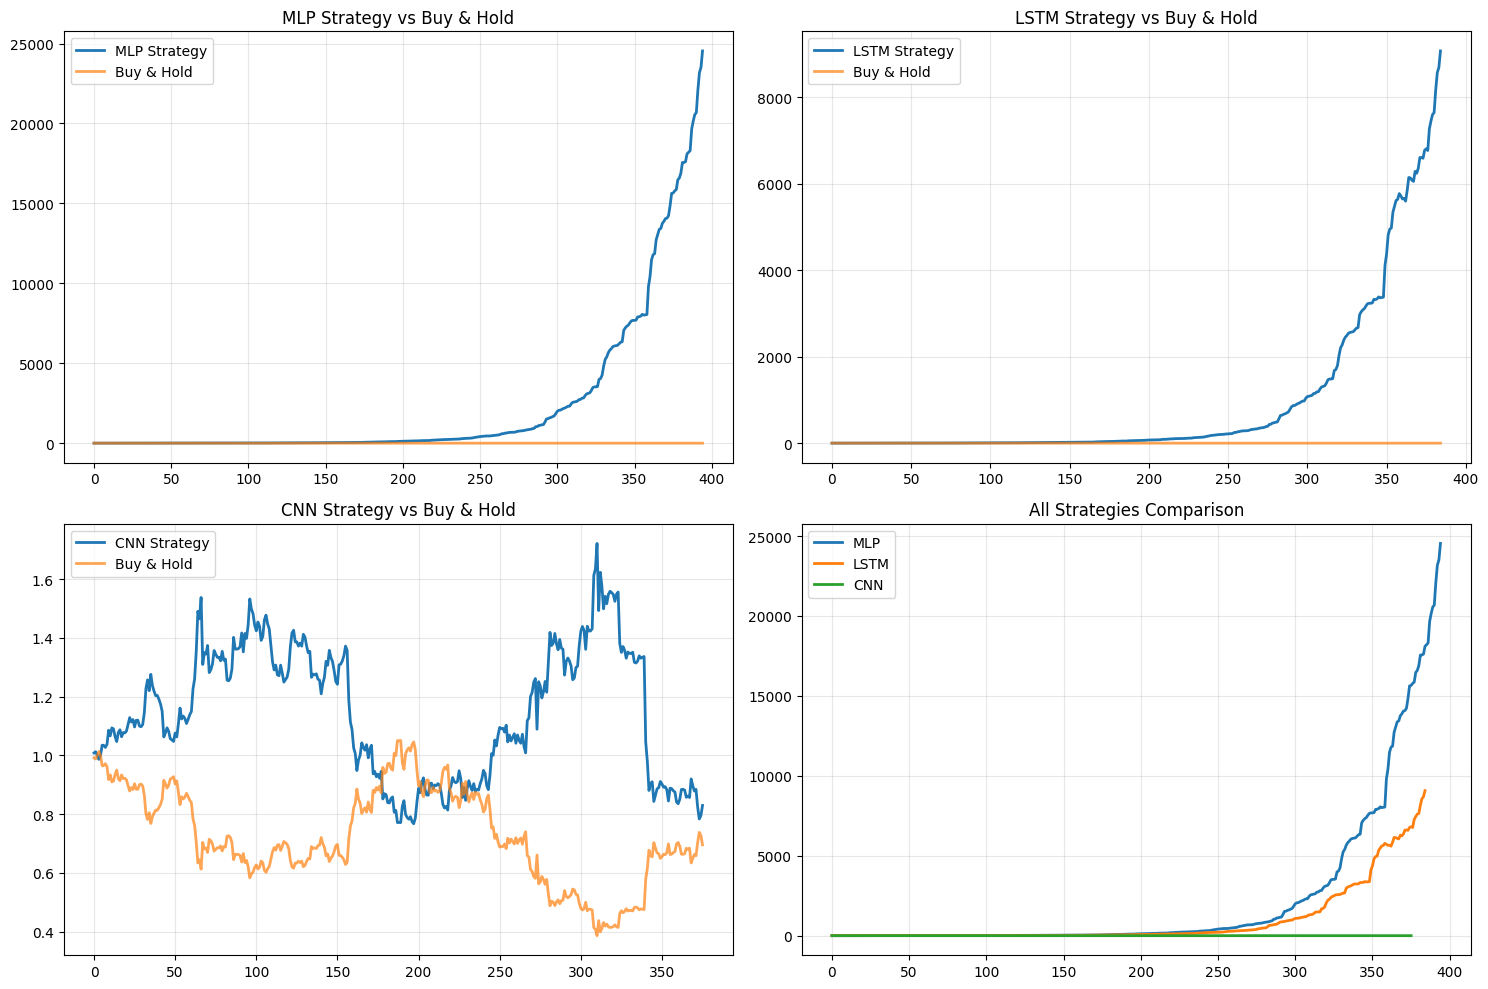

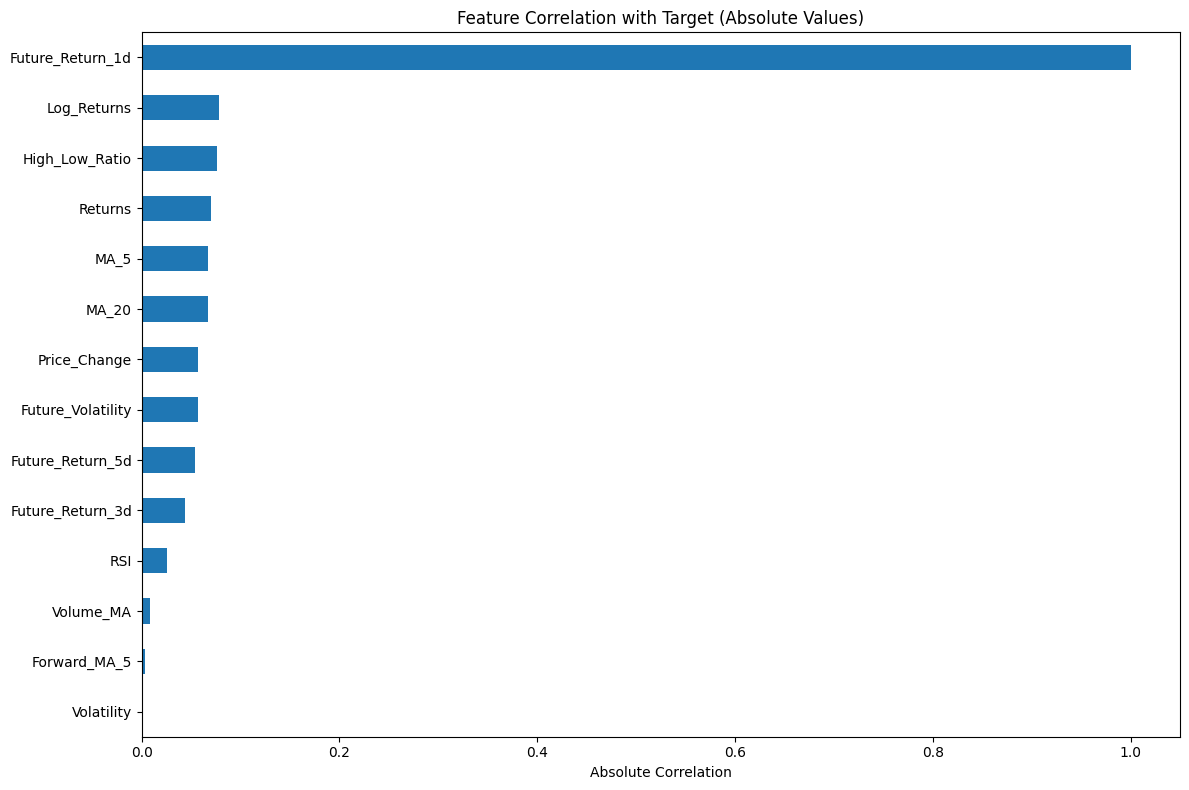

In [ ]:
# 12. Visualization
print("\n12. Creating visualizations...")

# Plot cumulative returns
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(mlp_bt['cumulative_returns'], label='MLP Strategy', linewidth=2)
plt.plot((1 + y_reg_test).cumprod(), label='Buy & Hold', linewidth=2, alpha=0.7)
plt.title('MLP Strategy vs Buy & Hold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(lstm_bt['cumulative_returns'], label='LSTM Strategy', linewidth=2)
plt.plot((1 + y_reg_test_seq).cumprod(), label='Buy & Hold', linewidth=2, alpha=0.7)
plt.title('LSTM Strategy vs Buy & Hold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(cnn_bt['cumulative_returns'], label='CNN Strategy', linewidth=2)
plt.plot((1 + y_reg_test_gaf).cumprod(), label='Buy & Hold', linewidth=2, alpha=0.7)
plt.title('CNN Strategy vs Buy & Hold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
# Comparison of all strategies
plt.plot(mlp_bt['cumulative_returns'], label='MLP', linewidth=2)
plt.plot(lstm_bt['cumulative_returns'], label='LSTM', linewidth=2)
plt.plot(cnn_bt['cumulative_returns'], label='CNN', linewidth=2)
plt.title('All Strategies Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance (correlation with target)
plt.figure(figsize=(12, 8))
correlations = pd.DataFrame(X_train_scaled, columns=feature_cols).corrwith(pd.Series(y_reg_train))
correlations.abs().sort_values(ascending=True).plot(kind='barh')
plt.title('Feature Correlation with Target (Absolute Values)')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()


# **Step 2**

### Backtesting the model using a walk forward method.

In [ ]:

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:

def load_eth_prices(start="2020-01-01", end=None):
    """Download ETH‑USD AdjClose from Yahoo Finance as a pandas Series."""
    if end is None:
        end = pd.Timestamp.today().strftime("%Y-%m-%d")
    df = yf.download("ETH-USD", start=start, end=end, auto_adjust=False, progress=False)
    # Adj Close is split‑/dividend‑adjusted – for crypto it's equal to Close.
    return df["Adj Close"].dropna().rename(columns={"Adj Close": "price"})

eth_price = load_eth_prices()
print(f"Fetched {len(eth_price)} daily observations from {eth_price.index[0].date()} to {eth_price.index[-1].date()}")

Fetched 1994 daily observations from 2020-01-01 to 2025-06-16


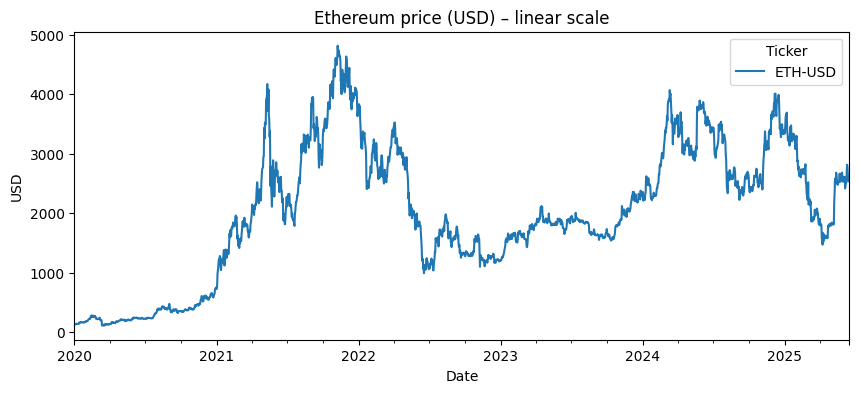

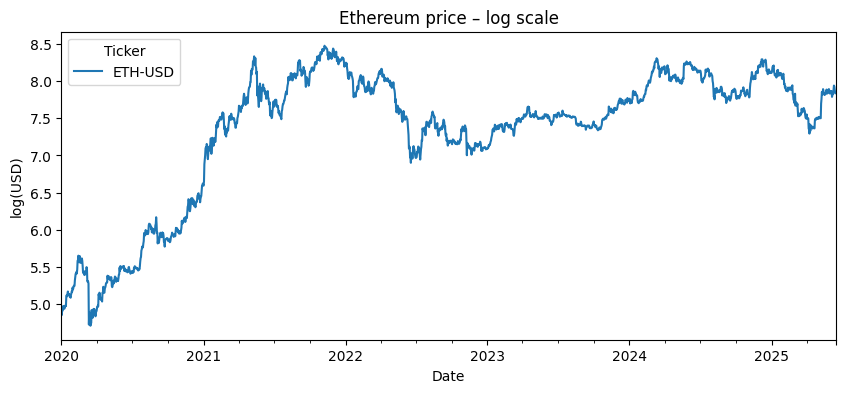


Descriptive statistics (USD price):
Ticker      ETH-USD
count   1994.000000
mean    2020.003387
std     1117.712048
min      110.605873
25%     1316.123688
50%     1900.029602
75%     2866.634460
max     4812.087402

Return statistics (%):
Ticker      ETH-USD
count   1993.000000
mean       0.244571
std        4.338041
min      -42.347221
25%       -1.753011
50%        0.138976
75%        2.203537
max       25.947533


/usr/local/lib/python3.11/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


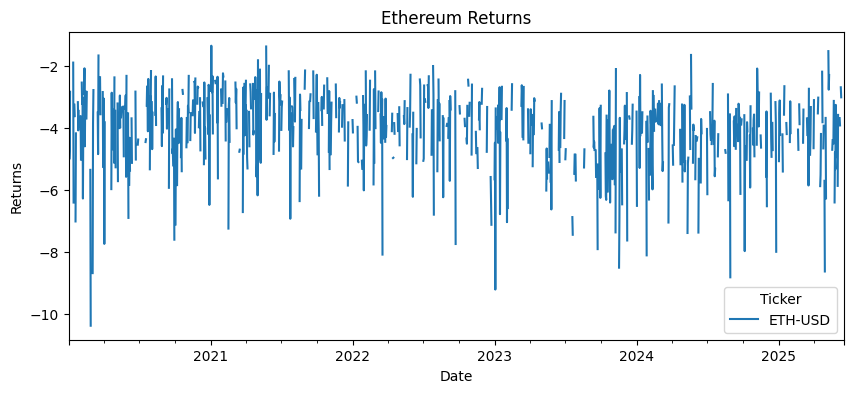

In [ ]:

fig, ax = plt.subplots(figsize=(10, 4))
eth_price.plot(ax=ax, title="Ethereum price (USD) – linear scale")
ax.set_ylabel("USD")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
np.log(eth_price).plot(ax=ax, title="Ethereum price – log scale")
ax.set_ylabel("log(USD)")
plt.show()

print("\nDescriptive statistics (USD price):")
print(eth_price.describe())

# daily returns
eth_ret = eth_price.pct_change().dropna()
print("\nReturn statistics (%):")
print((eth_ret * 100).describe())

fig, ax = plt.subplots(figsize=(10, 4))
np.log(eth_ret).plot(ax=ax, title="Ethereum Returns")
ax.set_ylabel("Returns")
plt.show()

In [ ]:

def create_sequences(series_values, lookback):
    """Transform 1‑D series (array‑like) into (samples, timesteps, features=1) and target (next‑step return)."""
    X, y = [], []
    for i in range(len(series_values) - lookback):
        X.append(series_values[i : i + lookback])
        y.append(series_values[i + lookback])
    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y)
    return X, y


def build_lstm_model(lookback):
    model = Sequential([
        LSTM(32, input_shape=(lookback, 1), return_sequences=False),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


def walk_forward_backtest(series, train_size, test_size, lookback=60, epochs=30, verbose=0):
    """
    Non‑anchored walk‑forward: rolls forward by *test_size* each iteration.
    Returns DataFrame with actual, prediction, rmse per window.
    """
    scaler = StandardScaler()
    results = []
    start = 0
    loop = 0
    while start + train_size + test_size + lookback < len(series):
        loop += 1
        train_slice_values = series.values[start : start + train_size + lookback]  # need lookback extra for first X
        test_slice_values  = series.values[start + train_size : start + train_size + test_size + lookback]

        # scale on train only
        scaler.fit(train_slice_values.reshape(-1, 1))
        train_scaled = scaler.transform(train_slice_values.reshape(-1, 1)).flatten()
        test_scaled  = scaler.transform(test_slice_values.reshape(-1 , 1)).flatten()

        # sequences
        X_train, y_train = create_sequences(train_scaled, lookback)
        X_test,  y_test  = create_sequences(test_scaled,  lookback)

        # model
        model = build_lstm_model(lookback)
        es = EarlyStopping(patience=3, restore_best_weights=True)
        model.fit(X_train, y_train, epochs=epochs, batch_size=32, validation_split=0.1,
                  callbacks=[es], verbose=verbose)

        preds = model.predict(X_test, verbose=0).flatten()
        rmse  = np.sqrt(mean_squared_error(y_test, preds))
        mae   = mean_absolute_error(y_test, preds)
        dir_acc = np.mean(np.sign(preds) == np.sign(y_test))

        # store window results (align indices to original series)
        window_end_dates = series.index[start + train_size + lookback : start + train_size + lookback + len(y_test)]
        df_win = pd.DataFrame({"actual": y_test, "pred": preds}, index=window_end_dates)
        df_win["rmse_window"] = rmse
        df_win["mae_window"]  = mae
        df_win["dir_acc_window"] = dir_acc
        df_win["window"] = loop
        results.append(df_win)

        start += test_size  # roll forward

    return pd.concat(results)


Running Configuration A: train=500, test=500 …


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Done. Windows completed: 2

Running Configuration B: train=500, test=100 …


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Done. Windows completed: 14

Configuration A summary:
RMSE avg      0.678959
RMSE std      0.197077
MAE avg       0.490625
DirAcc avg    0.547000
n windows     2.000000
dtype: float64

Configuration B summary:
RMSE avg       0.919009
RMSE std       0.312126
MAE avg        0.658201
DirAcc avg     0.512857
n windows     14.000000
dtype: float64


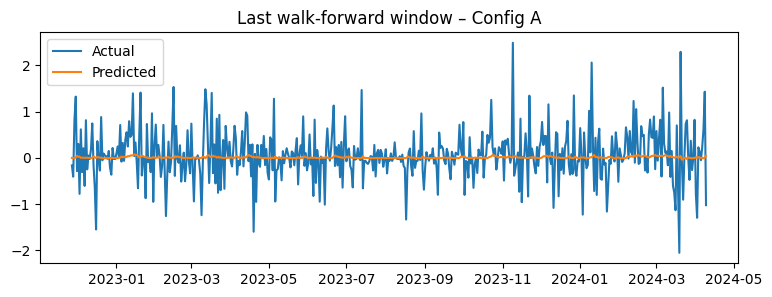

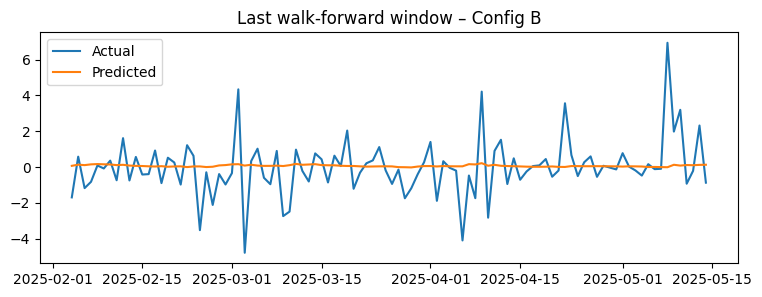

In [ ]:
#exectute backtests
LOOKBACK = 60
EPOCHS   = 20

print("\nRunning Configuration A: train=500, test=500 …")
res_A = walk_forward_backtest(eth_ret, 500, 500, lookback=LOOKBACK, epochs=EPOCHS)
print("Done. Windows completed:", res_A["window"].nunique())

print("\nRunning Configuration B: train=500, test=100 …")
res_B = walk_forward_backtest(eth_ret, 500, 100, lookback=LOOKBACK, epochs=EPOCHS)
print("Done. Windows completed:", res_B["window"].nunique())

# Plots
def summary_stats(df):
    return pd.Series({
        "RMSE avg":     df.groupby("window")["rmse_window"].first().mean(),
        "RMSE std":     df.groupby("window")["rmse_window"].first().std(),
        "MAE avg":      df.groupby("window")["mae_window"].first().mean(),
        "DirAcc avg":   df.groupby("window")["dir_acc_window"].first().mean(),
        "n windows":    df["window"].nunique()
    })

print("\nConfiguration A summary:")
print(summary_stats(res_A))

print("\nConfiguration B summary:")
print(summary_stats(res_B))

# Cumulative absolute return prediction plot for last window of each config
for label, res in zip(["A", "B"], [res_A, res_B]):
    last_window = res["window"].max()
    dfw = res[res["window"] == last_window]
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(dfw.index, dfw["actual"], label="Actual")
    ax.plot(dfw.index, dfw["pred"], label="Predicted")
    ax.set_title(f"Last walk‑forward window – Config {label}")
    ax.legend()
    plt.show()

In [ ]:
#Metrics per window
metric_A = res_A.groupby("window").first()[["rmse_window", "dir_acc_window"]]
metric_B = res_B.groupby("window").first()[["rmse_window", "dir_acc_window"]]

print("\nRMSE and Directional Accuracy per window (Config A):")
print(metric_A)

print("\nRMSE and Directional Accuracy per window (Config B):")
print(metric_B)


RMSE and Directional Accuracy per window (Config A):
        rmse_window  dir_acc_window
window                             
1          0.818313           0.580
2          0.539604           0.514

RMSE and Directional Accuracy per window (Config B):
        rmse_window  dir_acc_window
window                             
1          0.797021            0.50
2          0.796300            0.56
3          0.758936            0.49
4          1.073083            0.51
5          0.920050            0.55
6          0.543589            0.45
7          0.626765            0.54
8          0.455830            0.59
9          0.696395            0.39
10         1.016183            0.55
11         1.107527            0.49
12         1.220297            0.56
13         1.277531            0.53
14         1.576625            0.47


# **Step 3**

In [ ]:
def walk_forward_backtest_no_leakage(series, train_size, test_size, lookback=60, embargo=5, epochs=30, verbose=0):
    """
    Walk-forward with purging and embargo to reduce information leakage.
    """
    scaler = StandardScaler()
    results = []
    start = 0
    loop = 0

    while start + train_size + embargo + test_size + lookback < len(series):
        loop += 1

        # Apply embargo
        train_start = start
        train_end = start + train_size
        test_start = train_end + embargo
        test_end = test_start + test_size

        # Extract raw values
        train_slice = series.values[train_start : train_end + lookback]
        test_slice  = series.values[test_start : test_end + lookback]

        # Standardize using training set only
        scaler.fit(train_slice.reshape(-1, 1))
        train_scaled = scaler.transform(train_slice.reshape(-1, 1)).flatten()
        test_scaled  = scaler.transform(test_slice.reshape(-1, 1)).flatten()

        # Sequence creation
        X_train, y_train = create_sequences(train_scaled, lookback)
        X_test, y_test   = create_sequences(test_scaled, lookback)

        # LSTM Model
        model = build_lstm_model(lookback)
        es = EarlyStopping(patience=3, restore_best_weights=True)
        model.fit(X_train, y_train, epochs=epochs, batch_size=32,
                  validation_split=0.1, callbacks=[es], verbose=verbose)

        # Predictions and metrics
        preds = model.predict(X_test, verbose=0).flatten()
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae  = mean_absolute_error(y_test, preds)
        dir_acc = np.mean(np.sign(preds) == np.sign(y_test))

        # Time index for test results
        test_dates = series.index[test_start + lookback : test_start + lookback + len(y_test)]
        df_win = pd.DataFrame({"actual": y_test, "pred": preds}, index=test_dates)
        df_win["rmse_window"] = rmse
        df_win["mae_window"] = mae
        df_win["dir_acc_window"] = dir_acc
        df_win["window"] = loop
        results.append(df_win)

        start += test_size  # Move forward

    return pd.concat(results)


In [ ]:
print("\nStep 3b: No Leakage – Config A: train=500, test=500 …")
res_A_noleak = walk_forward_backtest_no_leakage(eth_ret, 500, 500, lookback=LOOKBACK, embargo=5, epochs=EPOCHS)
print("Done. Windows:", res_A_noleak["window"].nunique())

print("\nStep 3c: No Leakage – Config B: train=500, test=100 …")
res_B_noleak = walk_forward_backtest_no_leakage(eth_ret, 500, 100, lookback=LOOKBACK, embargo=5, epochs=EPOCHS)
print("Done. Windows:", res_B_noleak["window"].nunique())



Step 3b: No Leakage – Config A: train=500, test=500 …


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Done. Windows: 2

Step 3c: No Leakage – Config B: train=500, test=100 …


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Done. Windows: 14


In [ ]:
print("\nStep 3 – Config A summary:")
print(summary_stats(res_A_noleak))

print("\nStep 3 – Config B summary:")
print(summary_stats(res_B_noleak))



Step 3 – Config A summary:
RMSE avg      0.683977
RMSE std      0.196745
MAE avg       0.495015
DirAcc avg    0.474000
n windows     2.000000
dtype: float64

Step 3 – Config B summary:
RMSE avg       0.918797
RMSE std       0.311339
MAE avg        0.656983
DirAcc avg     0.491429
n windows     14.000000
dtype: float64
